In [2]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import sys
import argparse, logging

from matplotlib import pyplot as plt

import copy, numpy as np

import pycbc
from pycbc import events, bin_utils, results
from pycbc.events import triggers
from pycbc.events import trigger_fits as trstats
from pycbc.events import stat as pystat
from pycbc.io import HFile

#### MAIN ####

parser = argparse.ArgumentParser(usage="",
    description="Perform maximum-likelihood fits of single inspiral trigger"
                " distributions to various functions")
pycbc.add_common_pycbc_options(parser)
parser.add_argument("--trigger-file",
                    help="Input hdf5 file containing single triggers. "
                    "Required")
parser.add_argument("--bank-file", default=None,
                    help="hdf file containing template parameters. Required")
parser.add_argument("--veto-file", nargs='*', default=[], action='append',
                    help="File(s) in .xml format with veto segments to apply "
                    "to triggers before fitting")
parser.add_argument("--veto-segment-name", nargs='*', default=[], action='append',
                    help="Name(s) of veto segments to apply. Optional, if not "
                    "given all segments for a given ifo will be used")
parser.add_argument("--ifo", required=True,
                    help="Ifo producing triggers to be fitted. Required")
parser.add_argument("--fit-function",
                    choices=["exponential", "rayleigh", "power"],
                    help="Functional form for the maximum likelihood fit")
parser.add_argument("--stat-threshold", nargs="+", type=float,
                    help="Only fit triggers with statistic value above this "
                    "threshold : can be a space-separated list, then a fit "
                    "will be done for each threshold.  Required.  Typical "
                    "values 6.25 6.5 6.75")
parser.add_argument("--prune-param",
                    help="Parameter to define bins for 'pruning' loud triggers"
                    " to make the fit insensitive to signals and outliers. "
                    "Choose from mchirp, mtotal, template_duration or a named "
                    "frequency cutoff in pnutils or a frequency function in "
                    "LALSimulation")
parser.add_argument("--prune-bins", type=int,
                    help="Number of bins to divide bank into when pruning")
parser.add_argument("--prune-number", type=int,
                    help="Number of loudest events to prune in each bin")
parser.add_argument("--log-prune-param", action='store_true',
                    help="Bin in the log of prune-param")
parser.add_argument("--f-lower", type=float, default=0.,
                    help="Starting frequency for calculating template "
                    "duration; if not given, duration will be read from "
                    "single trigger files")
# FIXME : allow choice of SEOBNRv2/v4 or PhenD duration formula ?
parser.add_argument("--bin-param", required=True,
                    help="Parameter over which to bin when fitting. Required. "
                    "Choose from mchirp, mtotal, template_duration or a named "
                    "frequency cutoff in pnutils or a frequency function in "
                    "LALSimulation")
parser.add_argument("--bin-spacing", choices=["linear", "log", "irregular"],
                    help="How to space parameter bin edges")
binopt = parser.add_mutually_exclusive_group(required=True)
binopt.add_argument("--num-bins", type=int,
                    help="Number of regularly spaced bins to use over the "
                    " parameter")
binopt.add_argument("--irregular-bins",
                    help="Comma-separated list of parameter bin edges. "
                    "Required if --bin-spacing = irregular")
parser.add_argument("--bin-param-units",
                    help="String to display units of the binning parameter")
parser.add_argument("--approximant", default="SEOBNRv4",
                    help="Approximant for template duration. Default SEOBNRv4")
parser.add_argument("--min-duration", default=0.,
                    help="Fudge factor for templates with tiny or negative "
                    "values of template_duration: add to duration values "
                    "before fitting. Units seconds")
outputchoice = parser.add_mutually_exclusive_group()
outputchoice.add_argument("--plot-dir",
                    help="Plot the fits made, the variation of fitting "
                    "coefficients and the Kolmogorov-Smirnov test values "
                    "and save to the specified directory.")
outputchoice.add_argument("--output-file",
                    help="Output a plot of hists and fits made for a single "
                    "threshold value.")
parser.add_argument("--user-tag", default="",
                    help="Put a possibly informative string in the names of "
                    "plot files")

pystat.insert_statistic_option_group(parser,
    default_ranking_statistic='single_ranking_only')

In [3]:
args = parser.parse_args("--sngl-ranking newsnr_sgveto_psdvar_scaled_threshold \
        --statistic-keywords \
        --fit-function exponential \
        --stat-threshold 5.9 \
        --prune-param mtotal \
        --log-prune-param \
        --prune-bins 5 \
        --prune-number 3 \
        --bin-param mtotal \
        --f-lower 20.0 \
        --num-bins 8 \
        --bin-spacing log \
        --ifo H1 \
        --veto-segment-name closed_box \
        --veto-file /work/yifanwang/ecc/run/t6-cache-fixplotsingles/runs/O3/16/segments/H1L1V1-FOREGROUND_CENSOR-1248563828-631563.xml \
        --trigger-file /work/yifanwang/ecc/run/t6-cache-fixplotsingles/runs/O3/16/full_data/H1-HDF_TRIGGER_MERGE_FULL_DATA-1248563828-631563.hdf \
        --bank-file /work/yifanwang/ecc/run/t6-cache-fixplotsingles/runs/O3/16/bank/H1L1V1-BANK2HDF-1248563828-631563.hdf \
        --output-file H1-PLOT_BINNEDHIST_MTOTAL_FULL_DATA-1248563828-631563.png".split())

In [4]:
args

Namespace(verbose=0, version=None, trigger_file='/work/yifanwang/ecc/run/t6-cache-fixplotsingles/runs/O3/16/full_data/H1-HDF_TRIGGER_MERGE_FULL_DATA-1248563828-631563.hdf', bank_file='/work/yifanwang/ecc/run/t6-cache-fixplotsingles/runs/O3/16/bank/H1L1V1-BANK2HDF-1248563828-631563.hdf', veto_file=[['/work/yifanwang/ecc/run/t6-cache-fixplotsingles/runs/O3/16/segments/H1L1V1-FOREGROUND_CENSOR-1248563828-631563.xml']], veto_segment_name=[['closed_box']], ifo='H1', fit_function='exponential', stat_threshold=[5.9], prune_param='mtotal', prune_bins=5, prune_number=3, log_prune_param=True, f_lower=20.0, bin_param='mtotal', bin_spacing='log', num_bins=8, irregular_bins=None, bin_param_units=None, approximant='SEOBNRv4', min_duration=0.0, plot_dir=None, output_file='H1-PLOT_BINNEDHIST_MTOTAL_FULL_DATA-1248563828-631563.png', user_tag='', ranking_statistic='single_ranking_only', sngl_ranking='newsnr_sgveto_psdvar_scaled_threshold', statistic_files=[], statistic_keywords=[])

In [5]:
args.veto_file

[['/work/yifanwang/ecc/run/t6-cache-fixplotsingles/runs/O3/16/segments/H1L1V1-FOREGROUND_CENSOR-1248563828-631563.xml']]

# Read triggers and template bank

In [6]:
logging.info('Opening trigger file: %s' % args.trigger_file)
trigf = HFile(args.trigger_file, 'r')
logging.info('Opening template file: %s' % args.bank_file)
templatef = HFile(args.bank_file, 'r')

In [7]:
rank_method = pystat.get_statistic_from_opts(args, [args.ifo])

In [8]:
rank_method

In [9]:
stat = rank_method.get_sngl_ranking(trigf[args.ifo])

In [10]:
stat

array([4.00825  , 4.016282 , 4.3602176, ..., 3.9611268, 4.325544 ,
       4.1993628], dtype=float32)

In [11]:
len(stat)

81618312

In [12]:
min(stat), max(stat)

(1.0, 8.901348)

In [13]:
# stat threshold to reduce trigger numbers
minth = min(args.stat_threshold)
abovethresh = stat >= minth
stat = stat[abovethresh]
tid = trigf[args.ifo+'/template_id'][:][abovethresh]
time = trigf[args.ifo+'/end_time'][:][abovethresh]

In [14]:
len(stat)

11652

# Loundest trigger

In [17]:
for k in templatef.keys():
    print(k, templatef[k][tid[np.argmax(stat)]])

approximant b'SEOBNRv5E'
eccentricity 0.27237021517809307
f_lower 20.0
mass1 79.18319229560817
mass2 41.280624859639005
rel_anomaly 4.69691965259131
spin1z -0.326750982195819
spin2z 0.2012477956405621
template_duration 0.159667969
template_hash 5721101056680754969


In [22]:
l1_ranking = pystat.QuadratureSumStatistic('newsnr_sgveto_psdvar_scaled_threshold',None,['L1'])
l1_file = HFile('/work/yifanwang/ecc/run/t6-cache-fixplotsingles/runs/O3/16/full_data/L1-HDF_TRIGGER_MERGE_FULL_DATA-1248563828-631563.hdf', 'r')
l1_stat = l1_ranking.get_sngl_ranking(l1_file['L1'])

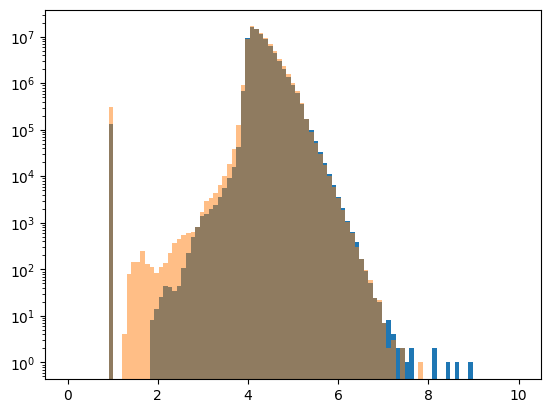

In [27]:
plt.hist(stat,bins= np.linspace(0, 10, 100))
plt.hist(l1_stat,bins= np.linspace(0, 10, 100),alpha=0.5)
plt.yscale('log')

In [29]:
l1_stat = l1_stat[l1_stat > args.stat_threshold]

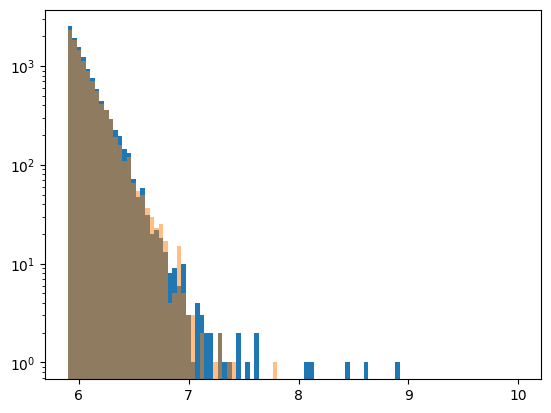

In [30]:
plt.hist(stat,bins= np.linspace(5.9, 10, 100))
plt.hist(l1_stat, bins= np.linspace(5.9, 10, 100),alpha=0.5)    
plt.yscale('log')

In [77]:
args.veto_segment_name = sum(args.veto_segment_name, [])
args.veto_file = sum(args.veto_file, [])

# now do vetoing
for veto_file, veto_segment_name in zip(args.veto_file, args.veto_segment_name):
    print(veto_file, veto_segment_name)
    retain, junk = events.veto.indices_outside_segments(time, [veto_file],
                             ifo=args.ifo, segment_name=veto_segment_name)
    stat = stat[retain]
    tid = tid[retain]
    time = time[retain]
    trig_dur = False
    if trig_dur:
        tdur = tdur[retain]
    logging.info('%i trigs left after vetoing with %s' %
                                                   (len(stat), args.veto_file))

/work/yifanwang/ecc/run/t6-cache-fixplotsingles/runs/O3/16/segments/H1L1V1-FOREGROUND_CENSOR-1248563828-631563.xml closed_box


In [78]:
len(stat)

11652

In [80]:
time

array([1.24875300e+09, 1.24905391e+09, 1.24913676e+09, ...,
       1.24882034e+09, 1.24859438e+09, 1.24880069e+09])

In [95]:
pbins = bin_utils.LogarithmicBins(10, 200, 8)

In [96]:
pbins

In [100]:
pbins.centres()

array([ 12.05908551,  17.53650826,  25.50186096,  37.0851998 ,
        53.9298699 ,  78.42564913, 114.04778934, 165.8500554 ])

In [101]:
pbins.lower(), pbins.upper()

(array([ 10.        ,  14.54215433,  21.14742527,  30.7529122 ,
         44.72135955,  65.03449126,  94.5741609 , 137.53120439]),
 array([ 14.54215433,  21.14742527,  30.7529122 ,  44.72135955,
         65.03449126,  94.5741609 , 137.53120439, 200.        ]))

In [97]:
binind = [pbins[c] for c in pbins.centres()]

In [98]:
binind

[0, 1, 2, 3, 4, 5, 6, 7]

In [104]:
m1, m2, s1z, s2z = triggers.get_mass_spin(templatef, tid)
binpars = triggers.get_param('mtotal', args, m1, m2, s1z, s2z)

pind = np.array([pbins[par] for par in binpars])

In [109]:
len(pind)

11652

In [111]:
i = binind[0]
vals_inbin = stat[pind == i]

In [112]:
vals_inbin

array([5.9019046, 6.073257 , 6.156631 , ..., 5.9045763, 5.905019 ,
       5.995235 ], dtype=float32)

In [113]:
len(vals_inbin)

6703

In [116]:
alpha, sig_alpha = trstats.fit_above_thresh(
                                             args.fit_function, vals_inbin, 5.9)

In [117]:
alpha

5.926532153274969

In [118]:
sig_alpha

0.07238790957785131

In [122]:
time[np.argmax(stat)]

1248615922.4990234

5

approximant b'SEOBNRv5E'
eccentricity 0.27237021517809307
f_lower 20.0
mass1 79.18319229560817
mass2 41.280624859639005
rel_anomaly 4.69691965259131
spin1z -0.326750982195819
spin2z 0.2012477956405621
template_duration 0.159667969
template_hash 5721101056680754969
